DATASET COMPARISON


,images,mean_width,mean_height,mean_polyp_area_percent,mean_polyps_per_image,mean_box_aspect_ratio,mean_brightness,mean_contrast
dataset,,,,,,,,
CVC-ClinicDB,612,384.000,288.000,9.166,1.056,1.163,76.195,54.166
Kvasir-SEG,1000,625.292,545.228,15.391,1.063,0.982,97.482,59.445


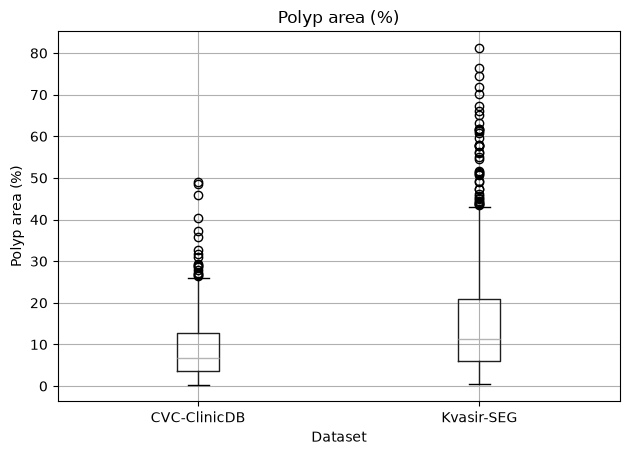

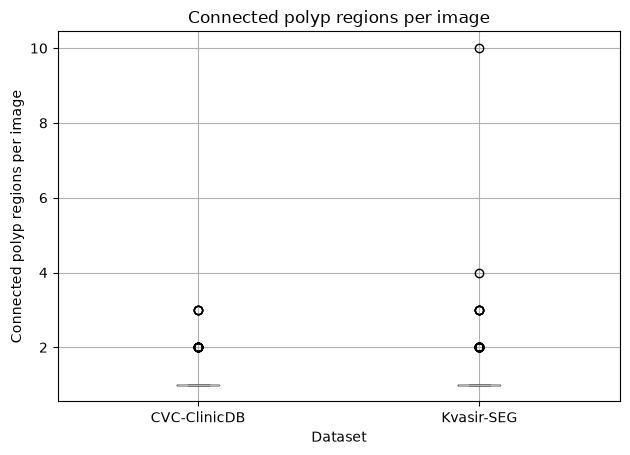

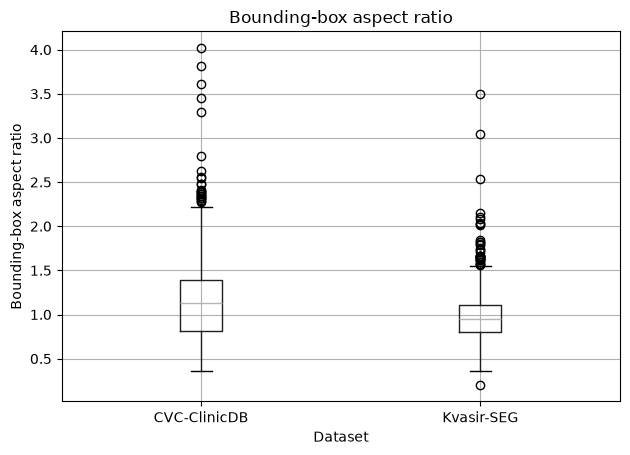

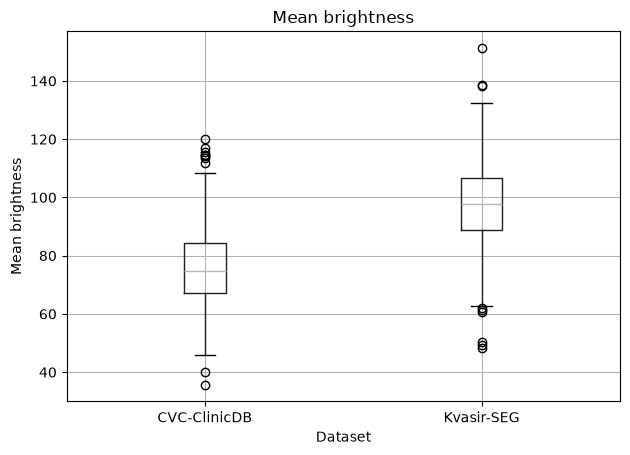

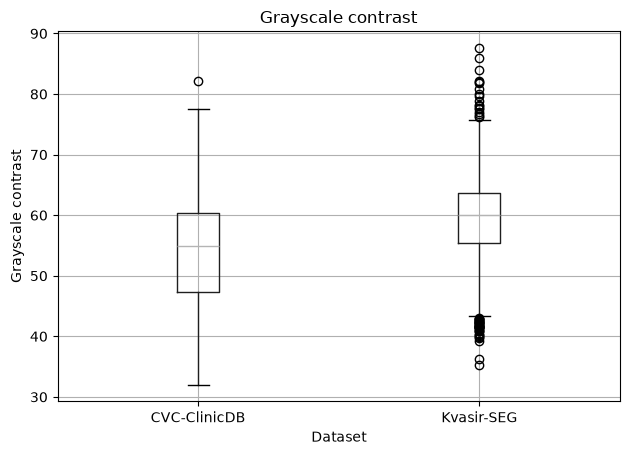

Kvasir images analysed: 1000
ClinicDB images analysed: 612
Files saved in: C:\Users\JUNCTION\Confidence-Aware-Self-Prompting-for-Robust-Polyp-Segmentation\notebooks


In [2]:

from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
OUT = ROOT / "notebooks"
OUT.mkdir(exist_ok=True)

def find_image(img_dir, mask_path):
    for ext in [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"]:
        candidate = img_dir / (mask_path.stem + ext)
        if candidate.exists():
            return candidate
    return None

def analyse_dataset(name, base, splits):
    rows = []

    for split in splits:
        img_dir = base / "images" / split
        mask_dir = base / "masks" / split

        if not mask_dir.exists() or not img_dir.exists():
            print(f"Skipping missing folders: {name}/{split}")
            continue

        for mask_path in sorted(mask_dir.iterdir()):
            if mask_path.suffix.lower() not in [
                ".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"
            ]:
                continue

            img_path = find_image(img_dir, mask_path)
            if img_path is None:
                continue

            img = cv2.imread(str(img_path))
            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

            if img is None or mask is None:
                continue

            h, w = mask.shape
            binary = (mask > 127).astype(np.uint8)
            area_percent = binary.mean() * 100

            count, _, stats, _ = cv2.connectedComponentsWithStats(binary)
            min_area = max(1, int(binary.size * 0.0005))
            boxes = []

            for i in range(1, count):
                x, y, bw, bh, component_area = stats[i]
                if component_area >= min_area and bh > 0:
                    boxes.append(bw / bh)

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            rows.append({
                "dataset": name,
                "split": split,
                "image": img_path.name,
                "width": w,
                "height": h,
                "polyp_area_percent": area_percent,
                "polyps_per_image": len(boxes),
                "box_aspect_ratio_mean": (
                    float(np.mean(boxes)) if boxes else np.nan
                ),
                "brightness": float(gray.mean()),
                "contrast": float(gray.std())
            })

    return pd.DataFrame(rows)

kvasir = analyse_dataset(
    "Kvasir-SEG",
    ROOT / "data" / "processed" / "kvasir",
    ["train", "val", "test"]
)

clinic = analyse_dataset(
    "CVC-ClinicDB",
    ROOT / "data" / "processed" / "cvc-clinicdb",
    ["test"]
)

df = pd.concat([kvasir, clinic], ignore_index=True)

if df.empty:
    raise ValueError("No images were analysed. Check the dataset folders.")

df.to_csv(OUT / "dataset_statistics.csv", index=False)

summary = df.groupby("dataset").agg(
    images=("image", "count"),
    mean_width=("width", "mean"),
    mean_height=("height", "mean"),
    mean_polyp_area_percent=("polyp_area_percent", "mean"),
    mean_polyps_per_image=("polyps_per_image", "mean"),
    mean_box_aspect_ratio=("box_aspect_ratio_mean", "mean"),
    mean_brightness=("brightness", "mean"),
    mean_contrast=("contrast", "mean")
).round(3)

print("DATASET COMPARISON")
display(summary)
summary.to_csv(OUT / "dataset_comparison.csv")

metrics = [
    ("polyp_area_percent", "Polyp area (%)"),
    ("polyps_per_image", "Connected polyp regions per image"),
    ("box_aspect_ratio_mean", "Bounding-box aspect ratio"),
    ("brightness", "Mean brightness"),
    ("contrast", "Grayscale contrast")
]

for column, title in metrics:
    plot_data = df.dropna(subset=[column])
    if plot_data.empty:
        continue

    plot_data.boxplot(column=column, by="dataset")
    plt.title(title)
    plt.suptitle("")
    plt.xlabel("Dataset")
    plt.ylabel(title)
    plt.tight_layout()
    plt.savefig(OUT / f"{column}.png", dpi=150)
    plt.show()
    plt.close()

print(f"Kvasir images analysed: {len(kvasir)}")
print(f"ClinicDB images analysed: {len(clinic)}")
print(f"Files saved in: {OUT.resolve()}")